**Description**: sanity check that training isn't bottlenecked by dataloading.

Result from training: it's not bottlenecked. GPU util is 90-100%. All dataloading takes a few min on my machine,
training takes a few hours. Tokenizer is fast.

TODO: run on GPU to include device transfer time.

**Expected time**: 8 min.

In [1]:
from collections import Counter
import time

import numpy as np
import seaborn as sns
from sentence_transformers import SentenceTransformer
import torch
from tqdm.auto import tqdm

import grouping_trainer as gt

In [2]:
sns.set_theme(style="darkgrid")

In [3]:
def record_times(times: list[float]):
    def decorator(func):
        def wrapper(*args, **kwargs):
            start_time = time.monotonic()
            result = func(*args, **kwargs)
            end_time = time.monotonic()
            times.append(end_time - start_time)
            return result

        return wrapper

    return decorator

In [ ]:
times_dedupe_sec: list[float] = []
times_tokenize_sec: list[float] = []

In [5]:
@record_times(times_dedupe_sec)
def dedupe(queries: list[str], candidates: list[str]) -> tuple[list[str], torch.Tensor]:
    texts_unique, inverse_indices = np.unique(queries + candidates, return_inverse=True)
    inverse_indices = torch.as_tensor(inverse_indices)
    return texts_unique.tolist(), inverse_indices

In [6]:
@record_times(times_tokenize_sec)
def tokenize(model: SentenceTransformer, texts_unique: list[str]) -> dict[str, torch.Tensor]:
    encodings = model.tokenize(texts_unique, return_tensors="pt", padding=True)
    encodings = {k: v.to(model.device) for k, v in encodings.items()}
    return encodings

In [7]:
def preprocess(model: SentenceTransformer, queries: list[str], candidates: list[str]) -> dict[str, torch.Tensor]:
    texts_unique, _ = dedupe(queries, candidates)
    encodings = tokenize(model, texts_unique)
    return encodings

In [8]:
model = gt.utils.SentenceTransformer("Alibaba-NLP/gte-modernbert-base")
training_config_full = gt.train.TrainingConfig(
    run_shortname="dummy",
    per_device_train_batch_size=64,
    gradient_accumulation_steps=16,  # unused here
    per_device_token_budget=8192 * 4,
)

In [9]:
trainer = gt.train.make_trainer(model, training_config_full)

Creating project datasets:   0%|          | 0/151 [00:00<?, ?it/s]

Packed 126 pairs from projects w/ fewer than 64 rows into a single dataset.
Training dataset: 141 projects, 835,765 pairs
Estimated 817 optimizer steps, logging every 16, saving every 81
Bias init: -1.2542


In [10]:
num_sub_batches_per_batch: list[int] = []

In [11]:
%%time
train_dataloader = trainer.get_train_dataloader()
for batch in tqdm(train_dataloader, total=len(train_dataloader)):
    for sub_batch_idx, sub_batch in enumerate(
        gt.train.batch_pairs_by_token_budget(batch, token_budget=training_config_full.per_device_token_budget)
    ):
        encodings = preprocess(
            trainer.model.encoder,
            sub_batch["query_stacktrace_string"],
            sub_batch["candidate_stacktrace_string"],
        )
    num_sub_batches_per_batch.append(sub_batch_idx + 1)

  0%|          | 0/13130 [00:00<?, ?it/s]

CPU times: user 33min 48s, sys: 2min 32s, total: 36min 20s
Wall time: 7min 17s


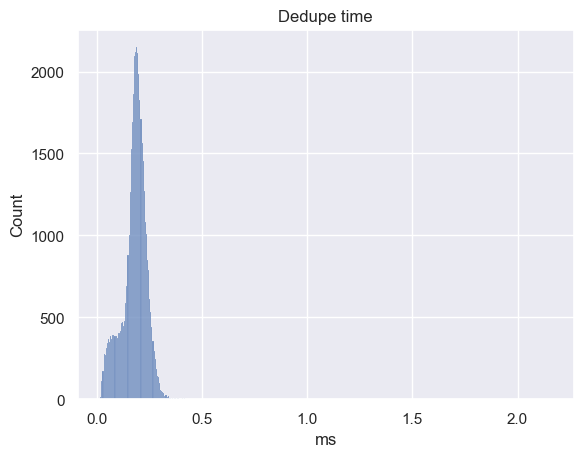

In [12]:
_ = sns.histplot(np.array(times_dedupe_sec) * 1_000).set(title="Dedupe time", xlabel="ms")

In [13]:
sum(times_dedupe_sec)

7.7489940939994995

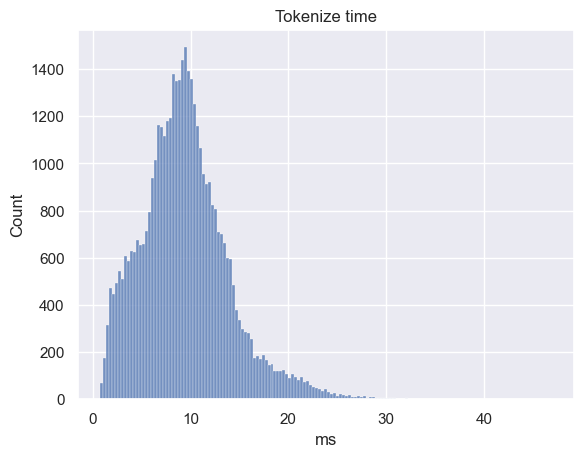

In [14]:
_ = sns.histplot(np.array(times_tokenize_sec) * 1_000).set(title="Tokenize time", xlabel="ms")

Likely we have a big set of small stacktraces.

In [15]:
sum(times_tokenize_sec)

405.79907605593326

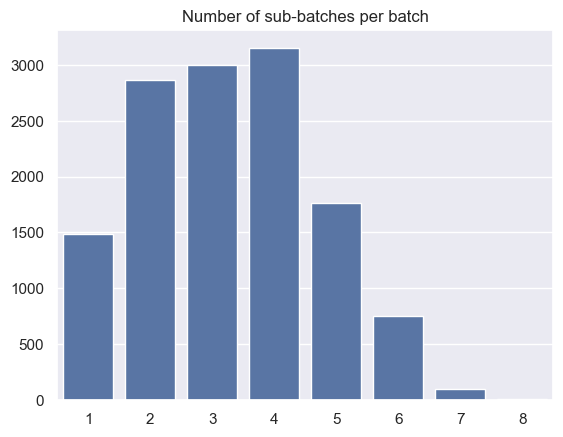

In [16]:
_ = sns.barplot(Counter(num_sub_batches_per_batch)).set(title="Number of sub-batches per batch")